**NOTE:** Some variable names differ from those used in the main text, 
reflecting terminology changes made during the course of the study:
- 'fold' -> 'lineage'
- 'NONE' -> 'base seed'
- 'ALL' -> 'full network'

Each enzyme-gated network expansion run records iterations of network expansion as follows:
- cumiter: Tracks all individual expansion steps, including both lineage addition steps and the resulting standard network expansion steps
- folditer: Groups each lineage addition and the subsequent network expansion into a single unit; corresponds to a metabolic stage

In [1]:
from utils import *
from sklearn.decomposition import PCA

In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [3]:
combined_df = pd.DataFrame()
dfs = {}

for pre in ['NONE', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL']:
    data_path = f'../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_{pre}.csv'
    
    df = pd.read_csv(data_path, index_col=0).T
    df = df.drop(['fold_independent', 'spontaneous'], errors='ignore', axis=1)
    dfs[pre] = df.copy()  # keep copies of df in 'dfs'
    df.index = [pre] * len(df)  # Set the prefix as the index for this DataFrame
    
    # Combine the DataFrames along rows
    combined_df = pd.concat([combined_df, df], axis=0)
    # randomize rows so that points overlap with each other
    combined_df = combined_df.sample(frac=1, random_state=42)
combined_df.head()

,2002,1,2487,2006,2003,246,304,4126,62,7542,...,4046,4025,4272,3281,3456,3843,3579,4036,4035,4054
C00010,2,7,42,4,3,15,9,130,129,43,...,368,365,366,367,369,369,370,373,373,373
Z00009,3,14,65,5,2,25,15,179,189,66,...,365,364,366,367,368,368,369,373,373,373
Z00047,2,7,48,4,3,19,8,141,139,50,...,364,363,365,366,370,370,371,372,372,372
C00016,2,6,43,4,3,15,9,128,142,44,...,368,365,365,366,371,371,372,373,373,373
Z00035,2,4,15,3,5,12,9,39,42,23,...,362,360,361,363,364,364,365,368,368,368


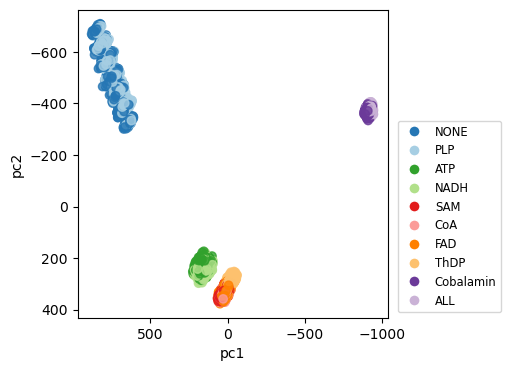

In [4]:
# reverse light vs. dark colors
pre2color = {'NONE': '#2576B4', 'Z00035': '#A6CEE3', 'C00002': '#31A12C', 'C00004': '#B1E08A', 'C00010': '#FB9B98', 'C00016': '#FF8000', 'C00019': '#E21C1C', 'Z00009': '#6B3A99', 'Z00047': '#FDC16E', 'ALL': '#CAB2D6'}
pre2label = {'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}
# Map index values to their corresponding colors
colors_by_label = combined_df.index.map(pre2color).tolist()
data = combined_df.values

pca = PCA(n_components=2)
principal_components = pca.fit_transform(data)

# Create a scatter plot with colored points based on the index labels
plt.figure(figsize=(4, 4))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=colors_by_label, alpha=0.8)
    
plt.xlabel('pc1')
plt.ylabel('pc2')

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

# add legend
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=pre2color[label], markersize=8, label=pre2label[label]) for label in pre2label.keys()]
# plt.legend(handles=legend_labels, loc="lower center", fontsize='small')
plt.legend(
    handles=legend_labels,
    loc="lower center",
    fontsize='small',
    bbox_to_anchor=(1.2, 0)  # Adjust position outside the plot
)

# plt.savefig('PCA.png', dpi=300, bbox_inches='tight')
plt.show()

# Lineage addition orders across different pre-expansion extents

In [5]:
pre2x2foMean = {}
pre2x2foStd = {}

for pre in ['NONE', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL']:

    # make df
    data_path = f'../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_{pre}.csv'
    df = pd.read_csv(data_path, index_col=0).T
    df = df.drop(['fold_independent', 'spontaneous'], errors='ignore', axis=1)
    df.index = [pre] * len(df)  # Set the prefix as the index for this DataFrame
    
    x2foMean = {}
    x2foStd = {}
    # calculate mean, std fold order for each fold
    for x in df.columns:
        x2foMean[x] = (np.mean(df[x])-1)  # -1 to correct for 'spontaneous'
        x2foStd[x] = (np.std(df[x]))

    pre2x2foMean[pre] = x2foMean
    pre2x2foStd[pre] = x2foStd

In [6]:
pre2x2foMean.keys()

dict_keys(['NONE', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL'])

In [7]:
# order by NONE lineage_order
dict1 = dict(sorted(pre2x2foMean['NONE'].items(), key=lambda item: item[1]))
dict2 = {k:pre2x2foMean['Z00035'][k] for k in dict1.keys()}
dict3 = {k:pre2x2foMean['C00002'][k] for k in dict1.keys()}
dict4 = {k:pre2x2foMean['C00004'][k] for k in dict1.keys()}
dict5 = {k:pre2x2foMean['C00019'][k] for k in dict1.keys()}
dict6 = {k:pre2x2foMean['C00010'][k] for k in dict1.keys()}
dict7 = {k:pre2x2foMean['C00016'][k] for k in dict1.keys()}
dict8 = {k:pre2x2foMean['Z00047'][k] for k in dict1.keys()}
dict9 = {k:pre2x2foMean['Z00009'][k] for k in dict1.keys()}
dict10 = {k:pre2x2foMean['ALL'][k] for k in dict1.keys()}

# Combine the dictionaries into a DataFrame
data = pd.DataFrame({
    'Base seed': dict1,
    'PLP': dict2,
    'ATP': dict3,
    'NADH': dict4,
    'SAM': dict5,
    'CoA': dict6,
    'FAD': dict7,
    'ThDP': dict8,
    'Cobalamin': dict9,
    'All metabolites': dict10
})  

In [8]:
# order by ATP lineage_order
dict1 = dict(sorted(pre2x2foMean['C00002'].items(), key=lambda item: item[1]))
dict2 = {k:pre2x2foMean['C00004'][k] for k in dict1.keys()}
dict3 = {k:pre2x2foMean['NONE'][k] for k in dict1.keys()}
dict4 = {k:pre2x2foMean['Z00035'][k] for k in dict1.keys()}
dict5 = {k:pre2x2foMean['C00019'][k] for k in dict1.keys()}
dict6 = {k:pre2x2foMean['C00010'][k] for k in dict1.keys()}
dict7 = {k:pre2x2foMean['C00016'][k] for k in dict1.keys()}
dict8 = {k:pre2x2foMean['Z00047'][k] for k in dict1.keys()}
dict9 = {k:pre2x2foMean['Z00009'][k] for k in dict1.keys()}
dict10 = {k:pre2x2foMean['ALL'][k] for k in dict1.keys()}

# Combine the dictionaries into a DataFrame
data = pd.DataFrame({
    'Base seed': dict3,
    'PLP': dict4,
    'ATP': dict1,
    'NADH': dict2,
    'SAM': dict5,
    'CoA': dict6,
    'FAD': dict7,
    'ThDP': dict8,
    'Cobalamin': dict9,
    'All metabolites': dict10
})  

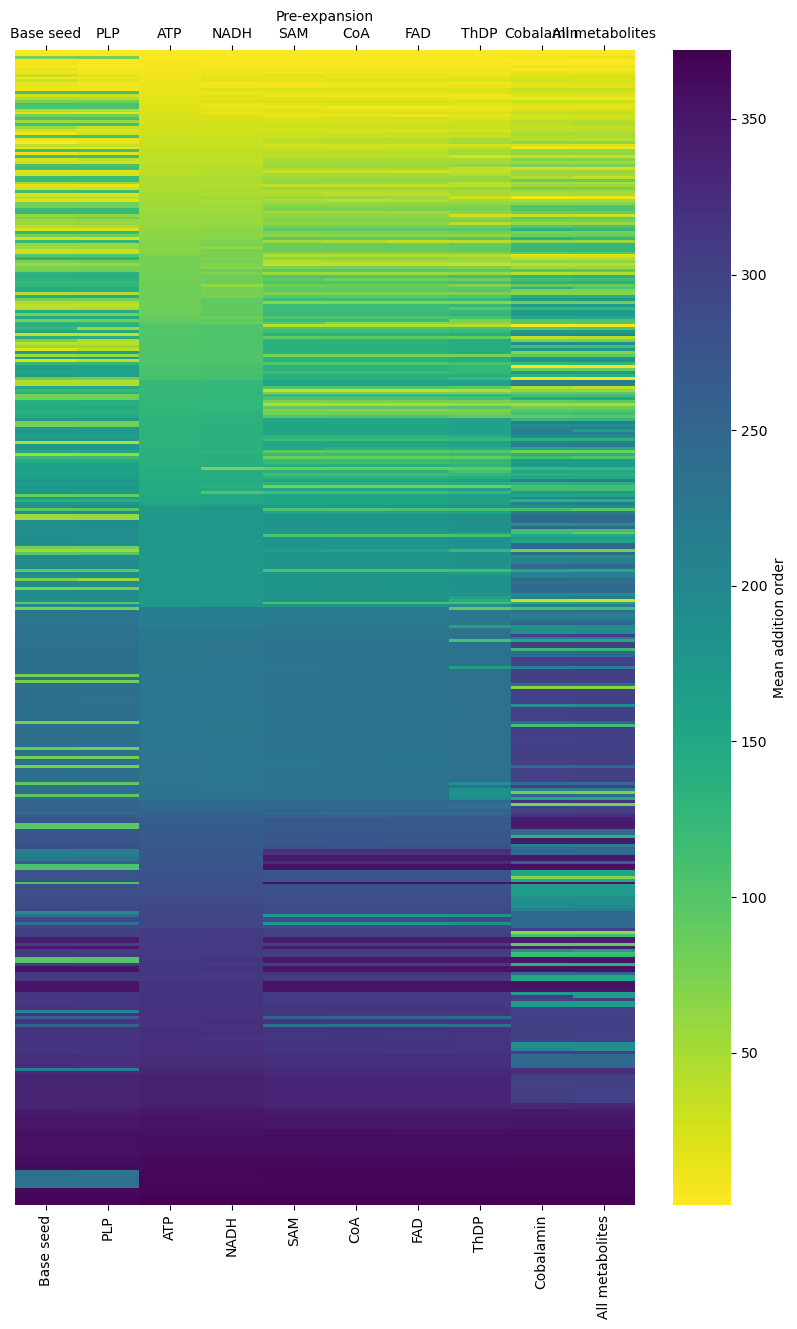

In [9]:
data.index = [x2name.get(k, f'X{k}') for k in data.index]  # Replace X with name

# Create the heatmap
plt.figure(figsize=(10, 15))
# sns.heatmap(data, cmap='viridis_r', annot=True, fmt=".1f", cbar_kws={'label': 'Mean addition order'})
sns.heatmap(data, cmap='viridis_r', cbar_kws={'label': 'Mean addition order'})

# Customize axis labels
plt.xlabel("Pre-expansion")
plt.ylabel("Lineages")

# Move the x-axis to the top
plt.gca().xaxis.set_label_position('top')
plt.gca().tick_params(axis='x', top=True, labeltop=True)

# Remove y-axis
plt.ylabel("")
plt.yticks([])  # Hides tick labels
plt.gca().tick_params(axis='y', left=False, right=False)  # Disables tick marks


# plt.savefig('fold_orders_pre-exp_all_pre_ATP2.svg', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
dict(sorted(pre2x2foMean['C00002'].items(), key=lambda item: item[1]))

{'2002': 1.0,
 '2006': 2.0,
 '2484': 3.0,
 '2003': 4.0,
 '2007': 5.0,
 '1': 6.0,
 '10': 7.0,
 '304': 8.0,
 '7527': 9.0,
 '246': 10.0,
 '805': 11.0,
 '12': 13.121,
 '11': 13.153,
 '7525': 14.542,
 '221': 14.547,
 '206': 14.637,
 '2004': 17.0,
 '2005': 18.0,
 '236': 19.0,
 '7524': 20.0,
 '4002': 21.0,
 '279': 22.0,
 '298': 23.0,
 '129': 24.0,
 '7510': 25.0,
 '159': 26.0,
 '5': 27.51,
 '2011': 27.729,
 '218': 28.761,
 '131': 30.0,
 '210': 31.973999999999997,
 '2487': 31.997999999999998,
 '7579': 32.028,
 '109': 34.506,
 '7531': 34.988,
 '7542': 35.506,
 '2486': 37.938,
 '7518': 38.017,
 '325': 38.045,
 '223': 41.492,
 '7581': 41.494,
 '281': 41.504,
 '301': 41.51,
 '222': 45.936,
 '7504': 46.207,
 '212': 46.272,
 '7515': 46.288,
 '7572': 46.318,
 '213': 47.979,
 '7577': 50.501,
 '7512': 50.998,
 '3016': 51.501,
 '103': 54.029,
 '4021': 54.456,
 '4004': 54.486,
 '3692': 55.029,
 '7516': 57.972,
 '328': 58.486,
 '247': 58.57,
 '208': 58.972,
 '286': 61.0,
 '7528': 63.0,
 '65': 63.4989999999

In [11]:
# order by ATP fold_order

dict1 = dict(sorted(pre2x2foMean['C00002'].items(), key=lambda item: item[1]))
dict1b = {k:pre2x2foStd['C00002'][k] for k in dict1.keys()}
dict2 = {k:pre2x2foMean['C00004'][k] for k in dict1.keys()}
dict2b = {k:pre2x2foStd['C00004'][k] for k in dict1.keys()}
dict3 = {k:pre2x2foMean['NONE'][k] for k in dict1.keys()}
dict3b = {k:pre2x2foStd['NONE'][k] for k in dict1.keys()}
dict4 = {k:pre2x2foMean['Z00035'][k] for k in dict1.keys()}
dict4b = {k:pre2x2foStd['Z00035'][k] for k in dict1.keys()}
dict5 = {k:pre2x2foMean['C00019'][k] for k in dict1.keys()}
dict5b = {k:pre2x2foStd['C00019'][k] for k in dict1.keys()}
dict6 = {k:pre2x2foMean['C00010'][k] for k in dict1.keys()}
dict6b = {k:pre2x2foStd['C00010'][k] for k in dict1.keys()}
dict7 = {k:pre2x2foMean['C00016'][k] for k in dict1.keys()}
dict7b = {k:pre2x2foStd['C00016'][k] for k in dict1.keys()}
dict8 = {k:pre2x2foMean['Z00047'][k] for k in dict1.keys()}
dict8b = {k:pre2x2foStd['Z00047'][k] for k in dict1.keys()}
dict9 = {k:pre2x2foMean['Z00009'][k] for k in dict1.keys()}
dict9b = {k:pre2x2foStd['Z00009'][k] for k in dict1.keys()}
dict10 = {k:pre2x2foMean['ALL'][k] for k in dict1.keys()}
dict10b = {k:pre2x2foStd['ALL'][k] for k in dict1.keys()}

# Combine the dictionaries into a DataFrame
data = pd.DataFrame({
    'Name': {k: x2name.get(k, f'X{k}') for k,v in dict1.items()},
    'Base seed (mean)': dict3,
    'Base seed (std.)': dict3b,
    'PLP (mean)': dict4,
    'PLP (std.)': dict4b,
    'ATP (mean)': dict1,
    'ATP (std.)': dict1b,
    'NADH (mean)': dict2,
    'NADH (std.)': dict2b,
    'SAM (mean)': dict5,
    'SAM (std.)': dict5b,
    'CoA (mean)': dict6,
    'CoA (std.)': dict6b,
    'FAD (mean)': dict7,
    'FAD (std.)': dict7b,
    'ThDP (mean)': dict8,
    'ThDP (std.)': dict8b,
    'Cobalamin (mean)': dict9,
    'Cobalamin (std.)': dict9b,
    'All metabolites (mean)': dict10,
    'All metabolites (std.)': dict10b
})  

In [12]:
data.head()

,Name,Base seed (mean),Base seed (std.),PLP (mean),PLP (std.),ATP (mean),ATP (std.),NADH (mean),NADH (std.),SAM (mean),...,CoA (mean),CoA (std.),FAD (mean),FAD (std.),ThDP (mean),ThDP (std.),Cobalamin (mean),Cobalamin (std.),All metabolites (mean),All metabolites (std.)
2002,TIM beta/alpha-barrel,1.000,0.000000,1.000,0.000000,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.000,0.000000,1.0,0.0,2.0,0.0,2.0,0.0
2006,HAD domain-like,4.000,0.000000,2.000,0.000000,2.0,0.0,3.0,0.0,3.0,...,3.0,0.0,3.000,0.000000,3.0,0.0,4.0,0.0,5.0,0.0
2484,Ribonuclease H-like,78.845,8.530239,81.399,7.925516,3.0,0.0,4.0,0.0,4.0,...,5.0,0.0,5.495,0.499975,5.0,0.0,10.0,0.0,12.0,0.0
2003,Rossmann-like,5.494,0.499964,4.000,0.000000,4.0,0.0,2.0,0.0,2.0,...,2.0,0.0,2.000,0.000000,2.0,0.0,1.0,0.0,1.0,0.0
2007,Flavodoxin-like,11.516,2.323735,5.000,0.000000,5.0,0.0,5.0,0.0,5.0,...,4.0,0.0,4.000,0.000000,4.0,0.0,3.0,0.0,3.0,0.0


In [13]:
# data.to_csv('mean_std_lineage_order_pre-expansions.csv')

## focus on 3 clusters, early lineages

In [14]:
pre2x2foMean['NONE']

{'2002': 1.0,
 '1': 2.0,
 '2487': 3.0,
 '2006': 4.0,
 '2003': 5.494,
 '246': 5.506,
 '304': 10.202,
 '4126': 22.409,
 '62': 21.972,
 '7542': 16.053,
 '218': 10.516,
 '2007': 11.516,
 '7525': 10.184,
 '12': 13.518,
 '11': 14.518,
 '109': 15.773,
 '10': 16.263,
 '210': 12.745,
 '7515': 18.021,
 '279': 19.021,
 '7577': 20.021,
 '3016': 21.021,
 '281': 22.021,
 '7528': 23.274,
 '331': 24.274,
 '301': 26.503,
 '7572': 26.524,
 '2011': 26.542,
 '325': 29.361,
 '206': 29.327,
 '805': 31.744,
 '7527': 31.642000000000003,
 '282': 30.541,
 '7529': 36.626,
 '7560': 36.841,
 '7512': 36.872,
 '3691': 36.816,
 '7518': 22.983,
 '180': 36.631,
 '7579': 36.725,
 '7554': 44.582,
 '286': 44.464,
 '4002': 44.239,
 '2004': 46.949,
 '70': 44.505,
 '297': 44.261,
 '205': 44.497,
 '315': 44.541,
 '7580': 46.962,
 '7571': 56.35,
 '7561': 56.336,
 '387': 56.584,
 '7510': 56.477,
 '5': 56.428,
 '307': 56.315,
 '7574': 56.603,
 '2': 56.516,
 '7567': 56.537,
 '208': 56.486,
 '247': 56.395,
 '7517': 60.464,
 '5104'

In [15]:
# collect the first n folds => union

num_folds = 11

d_NONE = dict(sorted(pre2x2foMean['NONE'].items(), key=lambda item: item[1]))
first_n_NONE = dict(islice(d_NONE.items(), num_folds))

d_C00002 = dict(sorted(pre2x2foMean['C00002'].items(), key=lambda item: item[1]))
first_n_C00002 = dict(islice(d_C00002.items(), num_folds))

d_ALL = dict(sorted(pre2x2foMean['ALL'].items(), key=lambda item: item[1]))
first_n_ALL = dict(islice(d_ALL.items(), num_folds))

# union
folds_union = set(first_n_NONE.keys()) | set(first_n_C00002.keys()) | set(first_n_ALL.keys())
len(folds_union)


# get foMean for the union folds
x2foMean_union_NONE = {}
for x in folds_union:
    x2foMean_union_NONE[x] = pre2x2foMean['NONE'][x]

x2foMean_union_C00002 = {}
for x in folds_union:
    x2foMean_union_C00002[x] = pre2x2foMean['C00002'][x]

x2foMean_union_ALL = {}
for x in folds_union:
    x2foMean_union_ALL[x] = pre2x2foMean['ALL'][x]


# order by NONE fold_order
# x2foMean_union_NONE = dict(sorted(x2foMean_union_NONE.items(), key=lambda item: item[1]))
# x2foMean_union_C00002 = {k:x2foMean_union_C00002[k] for k in x2foMean_union_NONE.keys()}
# x2foMean_union_ALL = {k:x2foMean_union_ALL[k] for k in x2foMean_union_NONE.keys()}

# order by ATP fold_order
x2foMean_union_C00002_od = dict(sorted(x2foMean_union_C00002.items(), key=lambda item: item[1]))
x2foMean_union_NONE_od = {k:x2foMean_union_NONE[k] for k in x2foMean_union_C00002.keys()}
x2foMean_union_ALL_od = {k:x2foMean_union_ALL[k] for k in x2foMean_union_NONE.keys()}

print(len(x2foMean_union_C00002_od))

21


In [16]:
# # instead, select the first n folds of ATP

# num_folds = 20

# d_C00002 = dict(sorted(pre2x2foMean['C00002'].items(), key=lambda item: item[1]))
# first_n_C00002 = dict(islice(d_C00002.items(), num_folds))

# d_NONE = dict(sorted(pre2x2foMean['NONE'].items(), key=lambda item: item[1]))
# first_n_NONE = {k:d_NONE[k] for k,v in first_n_C00002.items()}

# d_ALL = dict(sorted(pre2x2foMean['ALL'].items(), key=lambda item: item[1]))
# first_n_ALL = {k:d_ALL[k] for k,v in first_n_C00002.items()}


# # order by ATP fold_order
# x2foMean_union_C00002_od = dict(sorted(first_n_C00002.items(), key=lambda item: item[1]))
# x2foMean_union_NONE_od = {k:first_n_NONE[k] for k in x2foMean_union_C00002_od.keys()}
# x2foMean_union_ALL_od = {k:first_n_ALL[k] for k in x2foMean_union_C00002_od.keys()}

# print(len(x2foMean_union_C00002_od))

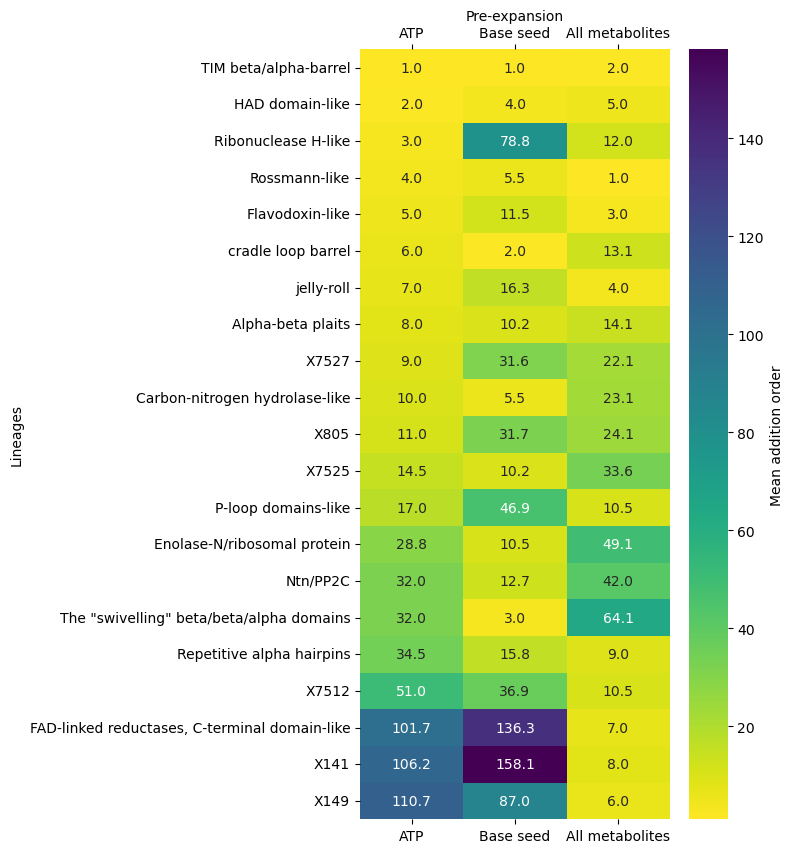

In [17]:
dict1 = x2foMean_union_C00002_od
dict2 = x2foMean_union_NONE_od
dict3 = x2foMean_union_ALL_od

# Combine the dictionaries into a DataFrame
data = pd.DataFrame({
    'ATP': dict1,
    'Base seed': dict2,
    'All metabolites': dict3
}) 

data.index = [x2name.get(k, f'X{k}') for k in data.index]  # Replace X with name

# Create the heatmap
plt.figure(figsize=(5, 10))
sns.heatmap(data, cmap='viridis_r', annot=True, fmt=".1f", cbar_kws={'label': 'Mean addition order'})
# sns.heatmap(data, cmap='viridis_r', cbar_kws={'label': 'Mean addition order'})

# Customize axis labels
plt.xlabel("Pre-expansion")
plt.ylabel("Lineages")

# Move the x-axis to the top
plt.gca().xaxis.set_label_position('top')
plt.gca().tick_params(axis='x', top=True, labeltop=True)

# Remove y-axis
# plt.ylabel("")
# plt.yticks([])  # Hides tick labels
# plt.gca().tick_params(axis='y', left=False, right=False)  # Disables tick marks


# plt.savefig(f'fold_orders_pre-exp_all_focus{num_folds}_union.svg', dpi=300, bbox_inches='tight')
plt.show()

## spearman's corr. b/w 3 clusters

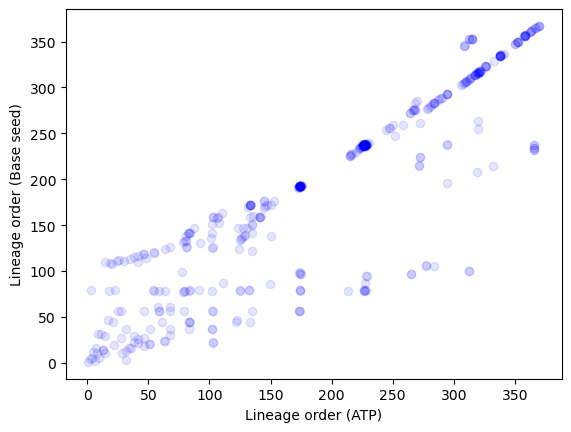

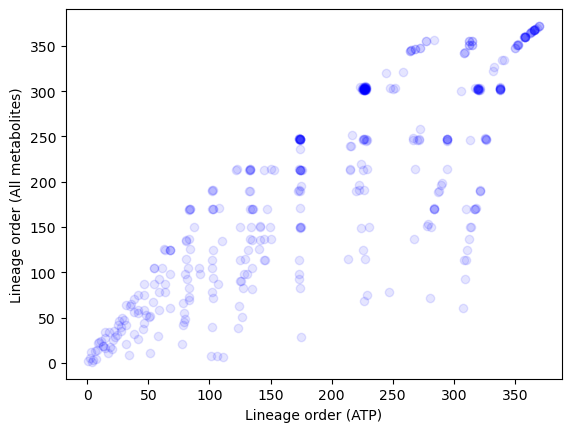

In [18]:
scatter(pre2x2foMean['C00002'], pre2x2foMean['NONE'], 'Lineage order (ATP)', 'Lineage order (Base seed)')
scatter(pre2x2foMean['C00002'], pre2x2foMean['ALL'], 'Lineage order (ATP)', 'Lineage order (All metabolites)')

In [19]:
# with ties
# x2rulesNum_rank = {key: rank for key, rank in zip(x2rulesNum_scope.keys(), rankdata(list(x2rulesNum_scope.values()), method='min'))}
# x2foMean_NONE_rank = {key: rank for key, rank in zip(pre2x2foMean['NONE'].keys(), rankdata(list(pre2x2foMean['NONE'].values()), method='min'))}
# x2foMean_ALL_rank = {key: rank for key, rank in zip(pre2x2foMean['ALL'].keys(), rankdata(list(pre2x2foMean['ALL'].values()), method='min'))}

# with ties (x is reversed)
x2rulesNum_scope = csv2dict('../data/assets/xgroup2/xgroup2rulesNum_scope.csv')
max_rank_x = max(rankdata(list(x2rulesNum_scope.values()), method='min'))
x2rulesNum_rankTie = {key: max_rank_x + 1 - rank for key, rank in zip(x2rulesNum_scope.keys(), rankdata(list(x2rulesNum_scope.values()), method='min'))}
x2foMean_C00002_rank = {key: rank for key, rank in zip(pre2x2foMean['C00002'].keys(), rankdata(list(pre2x2foMean['C00002'].values()), method='min'))}
x2foMean_NONE_rank = {key: rank for key, rank in zip(pre2x2foMean['NONE'].keys(), rankdata(list(pre2x2foMean['NONE'].values()), method='min'))}
x2foMean_ALL_rank = {key: rank for key, rank in zip(pre2x2foMean['ALL'].keys(), rankdata(list(pre2x2foMean['ALL'].values()), method='min'))}

In [20]:
def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis', savefig=False):
    fig, ax = plt.subplots()
    
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)

    if savefig:
        plt.savefig(f'scatter_{x_axis}_{y_axis}.png', dpi=300, bbox_inches='tight')
    
    plt.show()

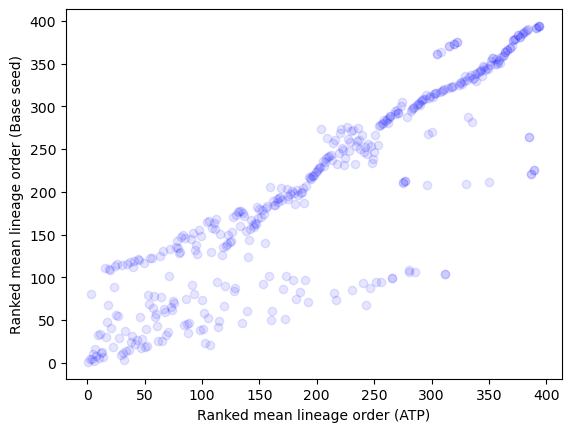

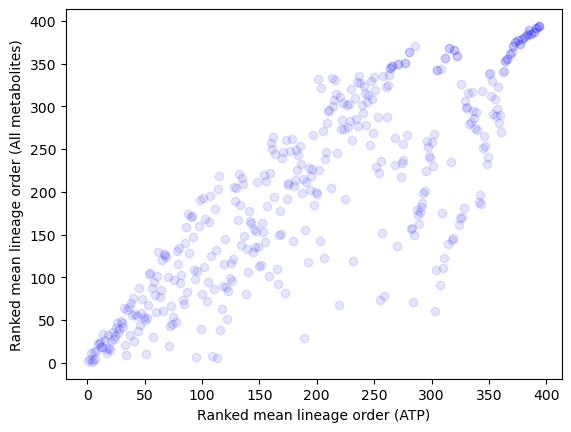

In [21]:
scatter(x2foMean_C00002_rank, x2foMean_NONE_rank, 'Ranked mean lineage order (ATP)', 'Ranked mean lineage order (Base seed)', savefig=False)
scatter(x2foMean_C00002_rank, x2foMean_ALL_rank, 'Ranked mean lineage order (ATP)', 'Ranked mean lineage order (All metabolites)', savefig=False)

# Seed set size of each pre-expansion

In [22]:
directory = "../data/pre-expansion_seed_cpds/" 

pre_exp2seed_size = {}
for filename in os.listdir(directory):
    file_path = os.path.join(directory, filename)
    
    pre_exp = filename.split('_')[-1].split('.')[0]
    with open(file_path, "rb") as file:
        data = pickle.load(file)
        pre_exp2seed_size[pre_exp] = len(data)
pre_exp2seed_size

{'Z00035': 255,
 'Z00009': 3995,
 'Z00047': 1550,
 'C00019': 1203,
 'C00002': 484,
 'C00016': 1353,
 'C00010': 1291,
 'C00004': 601,
 'ALL': 4294,
 'NONE': 80}

# lineage addition vs. multi-lineage injections for the various pre-expansions

In [23]:
dfs.keys()

dict_keys(['NONE', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'Z00009', 'ALL'])

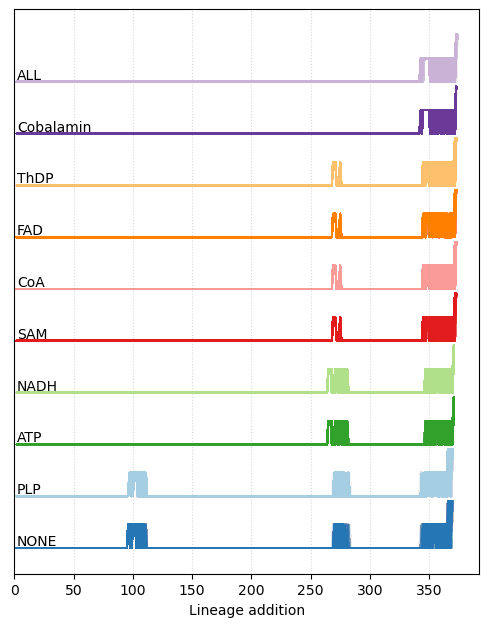

In [24]:
# Define vertical spacing between categories
spacing = 2.2  # Adjust to control separation
y_offset = 0  # Initial offset

plt.figure(figsize=(6, spacing * len(dfs) / 3))  # Single figure

for pre, df in dfs.items():
    # For each run in the DataFrame
    for _, row in df.iterrows():
        iter2foldsNum = {}
        for x, i in row.items():
            iter2foldsNum[int(i)] = iter2foldsNum.get(int(i), 0) + 1

        # Sort values for plotting
        od = OrderedDict(sorted(iter2foldsNum.items()))

        # Offset each plot vertically
        adjusted_values = [v + y_offset for v in od.values()]
        plt.plot(od.keys(), adjusted_values, color=pre2color[pre], alpha=0.01)

    # Add label at the left of each band
    plt.text(min(od.keys()), y_offset + 1, pre2label[pre], fontsize=10, verticalalignment='bottom')

    # Increase the offset for the next category
    y_offset += spacing  # Adjusts for non-overlapping placement

# Formatting
plt.xlabel("Lineage addition")
# plt.ylabel("Number of Lineages Added (offset for clarity)")
plt.yticks([])  # Remove y-ticks since we use labels instead
plt.xlim(left=0)  # Ensure x-axis starts at 0
plt.grid(axis="x", linestyle="dotted", alpha=0.5)  # Light grid for readability

# Save and show
# plt.savefig("multiple_injection_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

In [25]:
dfs['NONE']

,2002,1,2487,2006,2003,246,304,4126,62,7542,...,4046,4025,4272,3281,3456,3843,3579,4036,4035,4054
26262,2,3,4,5,6,7,8,9,10,11,...,361,362,363,364,365,365,366,367,367,367
47851,2,3,4,5,7,6,9,8,10,13,...,361,362,363,364,365,365,366,368,368,368
88490,2,3,4,5,6,7,8,9,35,11,...,361,362,363,364,366,366,367,369,369,369
92249,2,3,4,5,7,6,9,10,8,26,...,365,363,364,366,368,368,369,370,370,370
20023,2,3,4,5,7,6,9,12,11,8,...,364,362,362,365,367,367,368,369,369,369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79510,2,3,4,5,6,7,10,12,11,27,...,362,359,359,361,363,363,364,366,366,366
79955,2,3,4,5,7,6,9,8,11,27,...,363,362,364,365,366,366,367,368,368,368
6899,2,3,4,5,6,7,12,37,8,25,...,360,361,362,363,364,364,365,368,368,368
89690,2,3,4,5,7,6,16,10,9,12,...,363,362,364,365,366,366,367,368,368,368


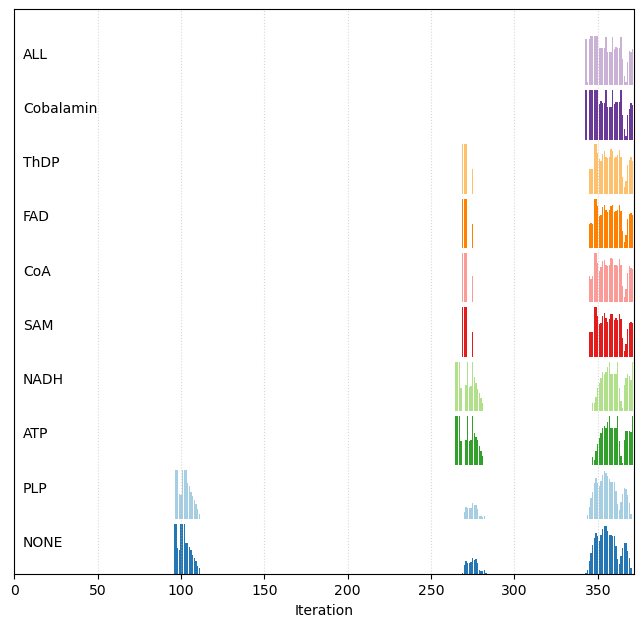

In [26]:
# Define vertical spacing between categories
spacing = 2.2  # Adjust to control separation
y_offset = 0  # Initial offset

plt.figure(figsize=(8, spacing * len(dfs)/ 3))  # Single figure

for pre, df in dfs.items():
    iter2multi = {}
    
    # For each run in the DataFrame
    for _, row in df.iterrows():
        
        # check iters with multi-lineage injection
        iter2foldsNum = {}
        for x, i in row.items():
            iter2foldsNum[int(i)] = iter2foldsNum.get(int(i), 0) + 1

        # record multi-lineage timing from each run
        for i, multi in iter2foldsNum.items():
            if multi > 1:
                iter2multi[int(i)] = iter2multi.get(int(i), 0) + 1

    # Sort values for plotting
    od = OrderedDict(sorted(iter2multi.items()))

    # get full range + shrink
    adjusted_values = [od.get(i, 0)/500 for i in range(372)]
    # adjusted_values = [od.get(i, 0) + y_offset for i in range(372)]
    plt.bar(list(range(372)), adjusted_values, color=pre2color[pre], alpha=1, bottom=y_offset)


    # Add label at the left of each band
    plt.text(5, y_offset + 1, pre2label[pre], fontsize=10, verticalalignment='bottom')

    # Increase the offset for the next category
    y_offset += spacing  # Adjusts for non-overlapping placement

# Formatting
plt.xlabel("Iteration")
# plt.ylabel("Number of Lineages Added (offset for clarity)")
plt.yticks([])  # Remove y-ticks since we use labels instead
plt.xlim(0, 372)  # Ensure x-axis starts at 0
plt.grid(axis="x", linestyle="dotted", alpha=0.5) 

# Save and show
# plt.savefig("multiple_injection_stacked_bars.png", dpi=300, bbox_inches='tight')
plt.show()

## histogram for oxygen discovery timing

In [27]:
oxy_timings = {}
for label in pre2label.keys():
    if label != 'ALL' and label != 'Z00009':  # remove ALL and cobalamin
        df = pd.read_csv(f'../data/1000runs_csvs/cpds_folditer_pre-expansion_1000runs/cpds_folditer_{label}.csv', index_col=0)
        timing = df.loc['C00007']
        oxy_timings[label] = timing

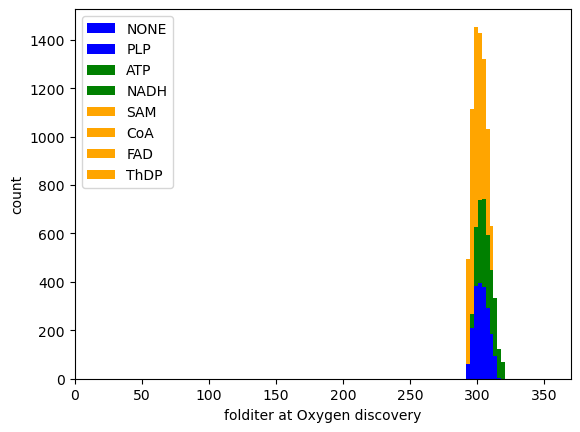

In [28]:
data = [list(oxy_timings[pre]) for pre in oxy_timings.keys()]

colors = ['blue', 'blue', 'green', 'green', 'orange', 'orange', 'orange', 'orange']
plt.hist(data, stacked=True, bins=10, color=colors, label=[pre2label.get(pre, pre) for pre in list(oxy_timings.keys())])
plt.xlabel('folditer at Oxygen discovery')
plt.xlim([0, 370])
plt.ylabel('count')
plt.legend(loc='upper left')
# plt.savefig('oxygen_discovery_timing_stacked_histogram.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# PCA loading analysis
Lineages whose addition order is affected the most by ∆ seed set

In [29]:
# define functions

def scatterColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis', line=False, cmap='bwr'):
    plt.figure(figsize=(4, 4))
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]
    
    plt.scatter(x_values, y_values, c=z_values, cmap=cmap, edgecolor='k', alpha=0.7)
    if line:
        plt.plot([0, max(y_values)], [0, max(x_values)], color='black', linestyle='--')
    
    # plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'scatterColor_{x_axis}_{y_axis}_{z_axis}.svg', dpi=300, bbox_inches='tight')
    plt.show()

def loglogColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis'):
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]
    
    plt.scatter(np.log10(x_values), np.log10(y_values), c=z_values, cmap='bwr', edgecolor='k', alpha=0.7)
    plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'loglogColor_{x_axis}_{y_axis}_{z_axis}.png')
    plt.show()

In [30]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'])
loadings

,PC1,PC2
0,-0.000645,-0.000555
1,-0.006367,-0.001381
2,-0.032569,0.009675
3,-0.001024,-0.001007
4,0.002196,-0.001174
...,...,...
391,-0.002565,0.002234
392,-0.002565,0.002234
393,-0.002889,0.002728
394,-0.002889,0.002728


In [31]:
x2loading1 = dict(zip(combined_df.keys(), loadings['PC1']))
x2loading2 = dict(zip(combined_df.keys(), loadings['PC2']))

## #rules vs. loading

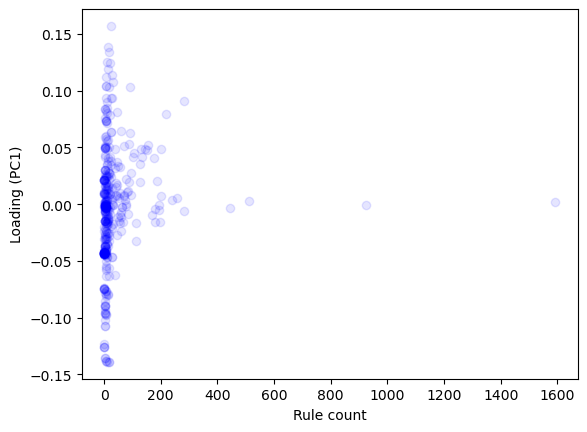

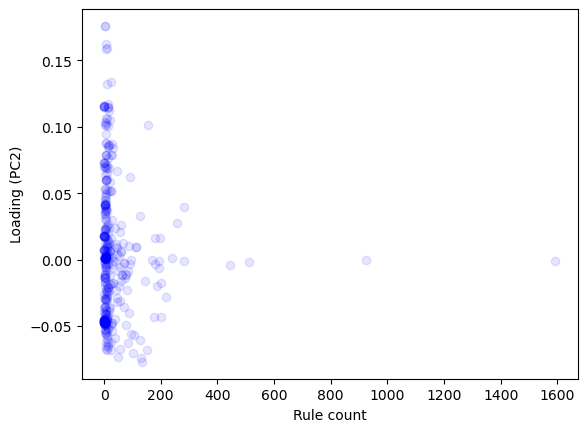

In [32]:
scatter(x2rulesNum_scope, x2loading1, 'Rule count', 'Loading (PC1)', savefig=False)
scatter(x2rulesNum_scope, x2loading2, 'Rule count', 'Loading (PC2)', savefig=False)

- PC1: folds with high/low loading have low #rules; 'specialized' folds have high or low loadings
- PC2: unclear what this represents

## Network size vs. loading

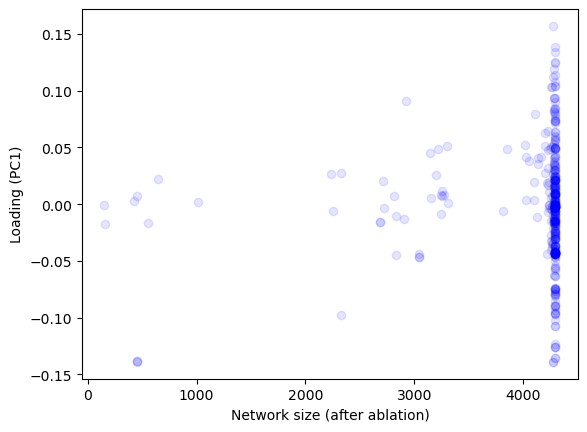

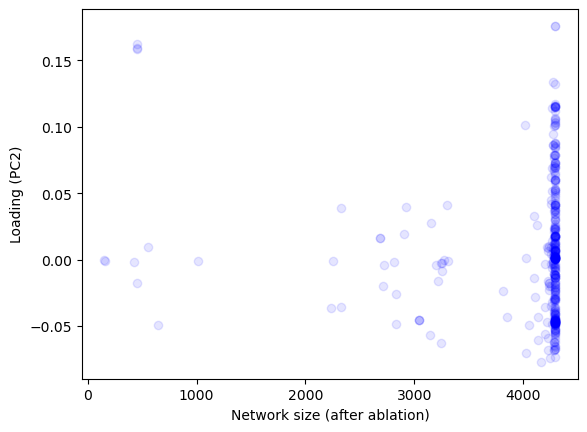

In [33]:
scatter(x2ns, x2loading1, 'Network size (after ablation)', 'Loading (PC1)')
scatter(x2ns, x2loading2, 'Network size (after ablation)', 'Loading (PC2)')

In [34]:
# codependent (≥50% multi-lineage additions) and single_rule from NONE
codependent = {'101', '144', '169', '184', '192', '2010', '223', '228', '278', '3018', '306', '3269', '3304', '3321', '3323', '3339', '3374', '3456', '3500', '355', '3623', '378', '3843', '3993', '4018', '4019', '4020', '4024', '4025', '4028', '4033', '4035', '4036', '4044', '4045', '4046', '4048', '4052', '4054', '4178', '4223', '4272', '4952', '4971', '590', '602', '604', '702', '75', '7507', '7544', '7546', '7563', '7578', '7586', '7587', '7601', '7602', '806', '812', '865', '872', '920'}
single_rule = {'1001', '102', '103', '107', '1114', '1143', '1144', '144', '149', '154', '164', '196', '197', '2010', '214', '223', '235', '237', '241', '2484', '2485', '2493', '2496', '2498', '258', '268', '278', '284', '285', '3001', '3009', '302', '305', '3076', '309', '3115', '316', '3207', '324', '328', '3281', '3339', '3374', '3456', '3651', '3685', '3687', '3697', '3752', '3777', '3843', '3847', '3892', '3960', '4011', '4017', '4019', '4021', '4022', '4024', '4025', '4029', '4044', '4046', '4111', '4160', '4161', '4229', '4237', '4272', '4295', '4335', '4952', '5039', '5067', '5069', '5100', '5103', '525', '528', '590', '602', '604', '608', '6096', '633', '64', '650', '702', '708', '7520', '7521', '7523', '7540', '7541', '7551', '7552', '7556', '7562', '7573', '7584', '7586', '7595', '7601', '7602', '7604', '813', '814', '842', '869', '876', '881', '9', '911'}

In [35]:
# PC1
p = figure(width=400, height=800)

# define data
d1 = x2ns
d2 = x2loading1

valid_keys, data1, data2 = todata(d1, d2)
# data1 = np.log10(data1)
labels = [x2name.get(key, key) for key in valid_keys]
colors = [
    'red' if (key in single_rule and key not in codependent) else 
    'blue' if (key in codependent and key not in single_rule) else 
    'purple' if (key in codependent and key in single_rule) else 
    'black' 
    for key in valid_keys
]

# source
source = ColumnDataSource(data={
    'x': data1,
    'y': data2,
    'label': labels,
    'color': colors
})

p.scatter('x', 'y', source=source, size=10, alpha=0.5, color='color', line_color=None)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("X", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'Network size'
p.yaxis.axis_label = 'Loading (PC1)'
# p.xaxis.ticker = [0, 50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# output_file("scatter.html")
show(p)

In [36]:
# PC2

p = figure(width=400, height=800)

# define data
d1 = x2ns
d2 = x2loading2

valid_keys, data1, data2 = todata(d1, d2)
# data1 = np.log10(data1)
labels = [x2name.get(key, key) for key in valid_keys]
colors = [
    'red' if (key in single_rule and key not in codependent) else 
    'blue' if (key in codependent and key not in single_rule) else 
    'purple' if (key in codependent and key in single_rule) else 
    'black' 
    for key in valid_keys
]

# source
source = ColumnDataSource(data={
    'x': data1,
    'y': data2,
    'label': labels,
    'color': colors
})

p.scatter('x', 'y', source=source, size=10, alpha=0.5, color='color', line_color=None)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("X", "@label")]
p.add_tools(hover)

# Customize plot
p.xaxis.axis_label = 'Network size'
p.yaxis.axis_label = 'Loading (PC2)'
# p.xaxis.ticker = [0, 50, 100, 150, 200, 250, 300, 350]  # Convert range to list
p.xgrid.grid_line_color = None

# output_file("scatter.html")
show(p)

## folditer vs. #rules vs. loading

In [37]:
# RANKED

# with ties
# x2rulesNum_rank = {key: rank for key, rank in zip(x2rulesNum_scope.keys(), rankdata(list(x2rulesNum_scope.values()), method='min'))}
# x2foMean_NONE_rank = {key: rank for key, rank in zip(pre2x2foMean['NONE'].keys(), rankdata(list(pre2x2foMean['NONE'].values()), method='min'))}
# x2foMean_ALL_rank = {key: rank for key, rank in zip(pre2x2foMean['ALL'].keys(), rankdata(list(pre2x2foMean['ALL'].values()), method='min'))}

# with ties (x is reversed)
max_rank_x = max(rankdata(list(x2rulesNum_scope.values()), method='min'))
x2rulesNum_rank = {key: max_rank_x + 1 - rank for key, rank in zip(x2rulesNum_scope.keys(), rankdata(list(x2rulesNum_scope.values()), method='min'))}
x2foMean_NONE_rank = {key: rank for key, rank in zip(pre2x2foMean['NONE'].keys(), rankdata(list(pre2x2foMean['NONE'].values()), method='min'))}
x2foMean_ATP_rank = {key: rank for key, rank in zip(pre2x2foMean['C00002'].keys(), rankdata(list(pre2x2foMean['C00002'].values()), method='min'))}
x2foMean_ALL_rank = {key: rank for key, rank in zip(pre2x2foMean['ALL'].keys(), rankdata(list(pre2x2foMean['ALL'].values()), method='min'))}

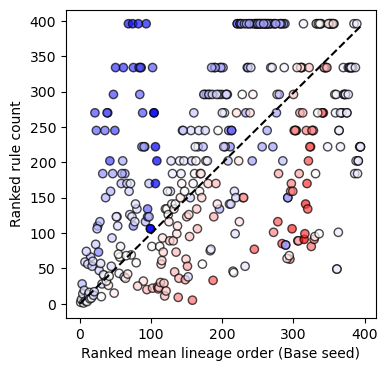

Lineage order (Base seed) vs. #rules: corr = -0.5343631943580014, p_value = 1.2780442542861007e-30


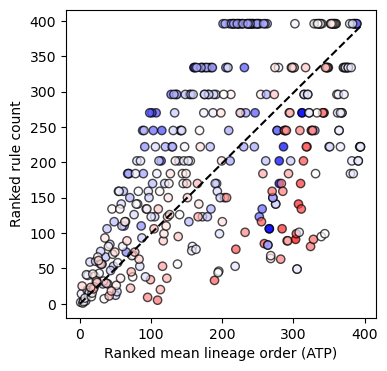

Lineage order (ATP) vs. #rules: corr = -0.6248090967302833, p_value = 2.898927813476995e-44


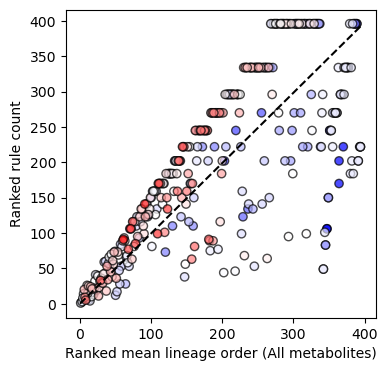

Lineage order (All metabolites) vs. #rules: corr = -0.7567771282116064, p_value = 9.466443311657558e-75


In [38]:
# loading 1
scatterColor(x2foMean_NONE_rank, x2rulesNum_rank, x2loading1, 'Ranked mean lineage order (Base seed)', 'Ranked rule count', 'Loading (PC1)', line=True)
corr, p = spearman(pre2x2foMean['NONE'], x2rulesNum_scope)
print(f'Lineage order (Base seed) vs. #rules: corr = {corr}, p_value = {p}')

scatterColor(x2foMean_ATP_rank, x2rulesNum_rank, x2loading1, 'Ranked mean lineage order (ATP)', 'Ranked rule count', 'Loading (PC1)', line=True)
corr, p = spearman(pre2x2foMean['C00002'], x2rulesNum_scope)
print(f'Lineage order (ATP) vs. #rules: corr = {corr}, p_value = {p}')

scatterColor(x2foMean_ALL_rank, x2rulesNum_rank, x2loading1, 'Ranked mean lineage order (All metabolites)', 'Ranked rule count', 'Loading (PC1)', line=True)
corr, p = spearman(pre2x2foMean['ALL'], x2rulesNum_scope)
print(f'Lineage order (All metabolites) vs. #rules: corr = {corr}, p_value = {p}')

## folditer vs. #rules vs. indepFrac

### make dict for indepFrac

In [39]:
rn2rules_scope = pd.read_pickle('../data/assets/rn2rules_scope.pkl')

#### Rule

In [40]:
def numIndepRuleWith(xgroup, rn2rules):
    numRule = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:  # rule contains only one fold => independent
                if xgroup == list(rule)[0]:
                    numRule += 1
    return numRule

# example
ex_dict = {}
ex_dict['a'] = {frozenset({'1'})}  # yes1
ex_dict['b'] = {frozenset({'1'}), frozenset({'2'})}  # yes1, yes2
ex_dict['c'] = {frozenset({'1', '2'})}  # no1, no2
ex_dict['d'] = {frozenset({'1', '2'}), frozenset({'1'})}  # yes1, no2
ex_dict['e'] = {frozenset({'1', '2'}), frozenset({'3'})}  # no1, no2; yes3

print(numIndepRuleWith('1', ex_dict))  # 3
print(numIndepRuleWith('2', ex_dict))  # 1
print(numIndepRuleWith('3', ex_dict))  # 1

print(numIndepRuleWith('2003', rn2rules))

3
1
1
1284


In [41]:
# rn2rules
x2indepRulesNum = {}
for xgroup in x2ns.keys():
    x2indepRulesNum[xgroup] = numIndepRuleWith(xgroup, rn2rules)

# rn2rules_scope
x2indepRulesNum_scope = {}
for xgroup in x2ns.keys():
    x2indepRulesNum_scope[xgroup] = numIndepRuleWith(xgroup, rn2rules_scope)

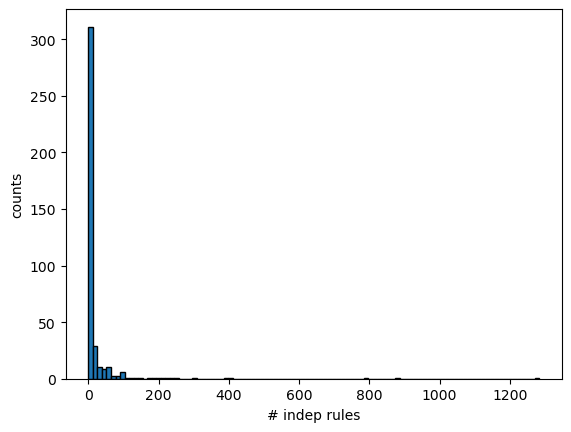

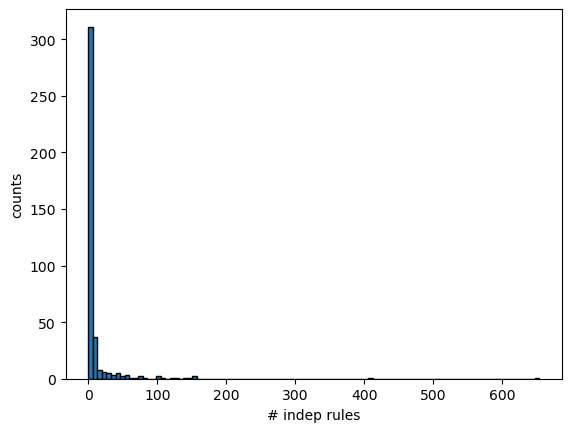

In [42]:
histogram(x2indepRulesNum, x_axis='# indep rules' ,bins=100)
histogram(x2indepRulesNum_scope, x_axis='# indep rules' ,bins=100)

In [43]:
# dict2csv(x2indepRulesNum, '../data/assets/xgroup2/xgroup2IndepRulesNum.csv')
# dict2csv(x2indepRulesNum_scope, '../data/assets/xgroup2/xgroup2IndepRulesNum_scope.csv')

In [44]:
# fraction
def numRulesWith(xgroup, rn2rules):
    numRules = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                numRules += 1
    return numRules

def numIndepRuleWith2(xgroup, rn2rules):
    numRule = 0
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:  # rule contains only one fold => independent
                if xgroup == list(rule)[0]:
                    numRule += 1
    return numRule / numRulesWith(xgroup, rn2rules)

In [45]:
numIndepRuleWith2('2003', rn2rules), numIndepRuleWith2('2003', rn2rules_scope)

(0.4181048518397916, 0.4105461393596987)

In [46]:
x2indepRulesFraction = {}
for xgroup in x2ns.keys():
    x2indepRulesFraction[xgroup] = numIndepRuleWith2(xgroup, rn2rules)

x2indepRulesFraction_scope = {}
for xgroup in x2ns.keys():
    x2indepRulesFraction_scope[xgroup] = numIndepRuleWith2(xgroup, rn2rules_scope)

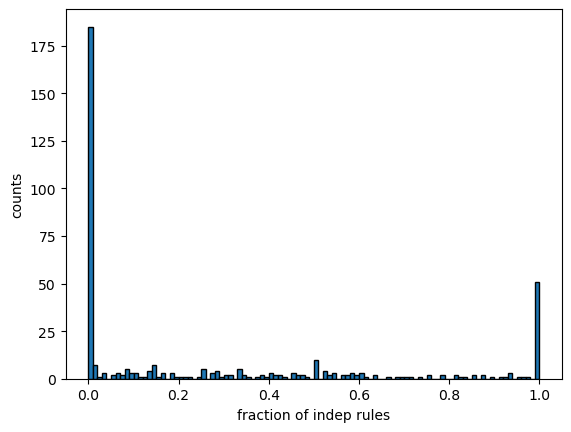

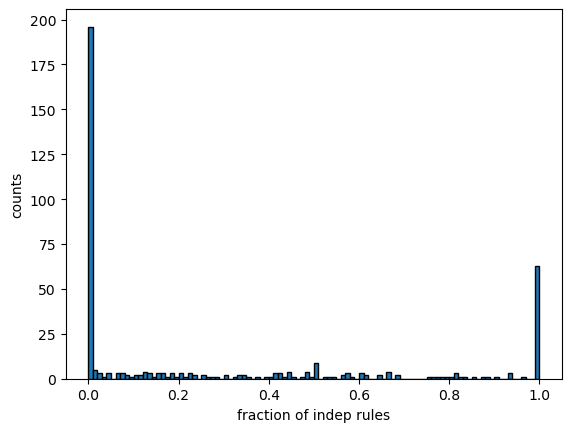

In [47]:
histogram(x2indepRulesFraction, x_axis='fraction of indep rules', bins=100)
histogram(x2indepRulesFraction_scope, x_axis='fraction of indep rules', bins=100)

In [48]:
# dict2csv(x2indepRulesFraction_scope, '../data/assets/xgroup2/xgroup2IndepRulesFraction_scope.csv')

#### Rn

In [49]:
def numIndepReactionWith(xgroup, rn2rules):
    result = {'indep':[], 'total':[]}
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if len(rule) == 1:
                if xgroup in rule:
                    result['indep'].append(reaction)
                    result['total'].append(reaction)
            elif xgroup in rule:
                result['total'].append(reaction)
    return result
# returns result = {'indep':[R1, R2], 'total':[R3, R4, R5]}

In [50]:
x2indepTotal = {}
for xgroup in x2ns.keys():
    x2indepTotal[xgroup] = numIndepReactionWith(xgroup, rn2rules_scope)

x2indepRnFrac = {}
for xgroup in x2ns.keys():
    x2indepRnFrac[xgroup] = len(x2indepTotal[xgroup]['indep'])/len(x2indepTotal[xgroup]['total'])

In [51]:
x2indepRnFrac['2003']

0.4105461393596987

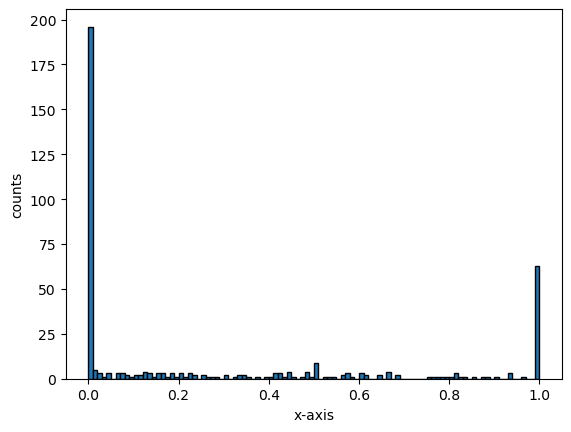

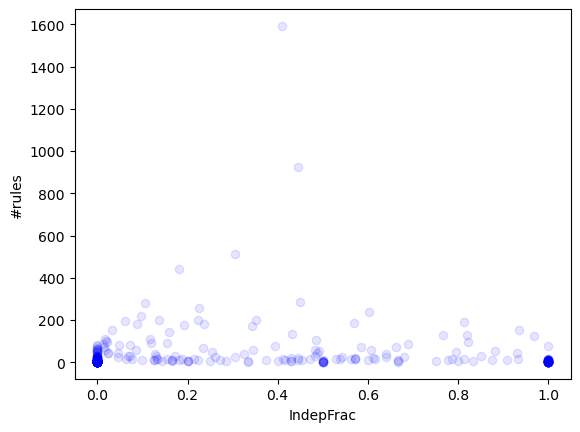

In [52]:
histogram(x2indepRnFrac, bins=100)
scatter(x2indepRnFrac, x2rulesNum_scope, 'IndepFrac', '#rules')

In [53]:
# dict2csv(x2indepRnFrac, '../data/assets/xgroup2/x2indepRnFrac.csv')

In [54]:
indep = set()
for x, frac in x2indepRnFrac.items():
    if frac > 0:  # independent
        if x != 'spontaneous':
            indep.add(x)
len(indep)

200

### plot

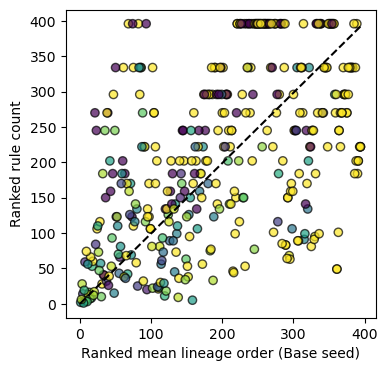

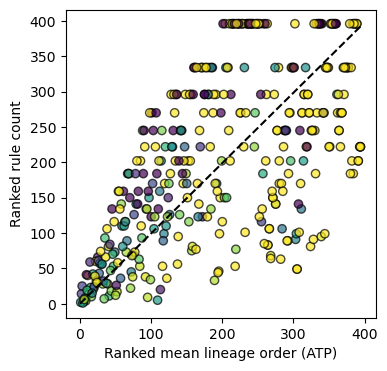

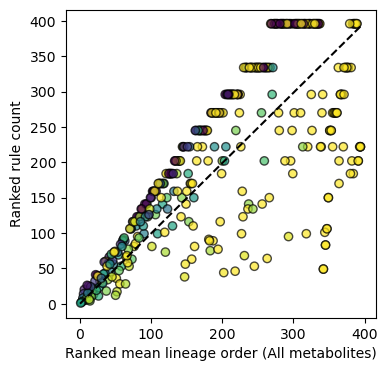

In [55]:
scatterColor(x2foMean_NONE_rank, x2rulesNum_rank, x2indepRnFrac, 'Ranked mean lineage order (Base seed)', 'Ranked rule count', 'Fraction of independent reactions', line=True, cmap='viridis_r')
scatterColor(x2foMean_ATP_rank, x2rulesNum_rank, x2indepRnFrac, 'Ranked mean lineage order (ATP)', 'Ranked rule count', 'Fraction of independent reactions', line=True, cmap='viridis_r')
scatterColor(x2foMean_ALL_rank, x2rulesNum_rank, x2indepRnFrac, 'Ranked mean lineage order (All metabolites)', 'Ranked rule count', 'Fraction of independent reactions', line=True, cmap='viridis_r')

## divide into above & below line => calculate enrichment

In [56]:
def barplot2(dx, dy, dz,  center, x_label='x', y_label='y', z_label='z', color1='red', color2='blue', title='', savefig=False):
    # Create a figure with adjustable subplot sizes
    fig = plt.figure(figsize=(7, 5))  # Overall figure size
    spec = fig.add_gridspec(1, 2, width_ratios=[4.2, 0.8])  # 2/3 width for scatter, 1/3 for bar plot
    
    ### --- SCATTER PLOT (Left, Larger) --- ###
    ax_scatter = fig.add_subplot(spec[0])
    xgroups = list(dz.keys())
    x_values = [dx[xgroup] for xgroup in xgroups]
    y_values = [dy[xgroup] for xgroup in xgroups]
    z_values = [dz[xgroup] for xgroup in xgroups]
    
    sc = ax_scatter.scatter(x_values, y_values, c=z_values, cmap='bwr', edgecolor='black', alpha=0.7)
    # sc = ax_scatter.scatter(x_values, y_values, c=z_values, cmap='bwr', edgecolors=plt.cm.bwr(z_values), alpha=0.7)
    ax_scatter.set_xlabel(x_label)
    ax_scatter.set_ylabel(y_label)

    cbar = plt.colorbar(sc, ax=ax_scatter, label=z_label)
    # Add diagonal line (y = x)
    min_val = min(min(dx.values()), min(dy.values()))
    max_val = max(max(dx.values()), max(dy.values()))
    ax_scatter.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')


    ### --- BAR PLOT (Right, Smaller) --- ###
    # Divide above/below by ratio of dy/dx
    above, below = [], []
    for x in dy.keys():
        ratio = dy[x] / dx[x] 
        above.append(x) if ratio >= 1 else below.append(x)
    
    redBelow, blueBelow, redAbove, blueAbove = [], [], [], []
    for x in below:
        (redBelow if dz[x] >= center else blueBelow).append(x)
    for x in above:
        (redAbove if dz[x] >= center else blueAbove).append(x)
    
    print('redAbove:', len(redAbove))
    print('blueAbove:', len(blueAbove))
    print('redBelow:', len(redBelow))
    print('blueBelow:', len(blueBelow))

    # plot bars
    values1 = [len(redAbove), len(redBelow)]
    values2 = [len(blueAbove), len(blueBelow)]
    bar_width = 0.4
    bar_positions = [0, 1]
    
    values1Frac = [values1[0]/(values1[0] + values2[0]), values1[1]/(values1[1] + values2[1])]
    values2Frac = [values2[0]/(values1[0] + values2[0]), values2[1]/(values1[1] + values2[1])]

    ax_bar = fig.add_subplot(spec[1])  # Bar plot on the right
    ax_bar.bar(bar_positions, values1Frac, linewidth=2, edgecolor=None, alpha=0.5, width=bar_width, color=color1)
    ax_bar.bar(bar_positions, values2Frac, bottom=values1Frac, linewidth=2, edgecolor=None, alpha=0.5, width=bar_width, color=color2)

    # Set labels
    ax_bar.set_xticks(bar_positions)
    ax_bar.set_xticklabels(['Above', 'Below'])
    ax_bar.set_ylabel('Fraction of lineages')
    # ax_bar.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=1)

    # Chi-square test
    contingency_table = np.array([[values1[0], values2[0]], [values1[1], values2[1]]])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    ax_bar.annotate(f'p = {format(p, ".2e")}', xy=(0.500, 1.10), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
    ax_bar.annotate('', xy=(0.1, 1.05), xytext=(0.9, 1.05), xycoords='axes fraction',
                    textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
    
    ax_bar.set_title(title, y=-0.2)

    plt.tight_layout()

    if savefig:
        plt.savefig(f'barplot2_{x_label}_{y_label}_{z_label}_{center}.svg', dpi=300, bbox_inches='tight')
    
    plt.show()

redAbove: 92
blueAbove: 128
redBelow: 50
blueBelow: 126


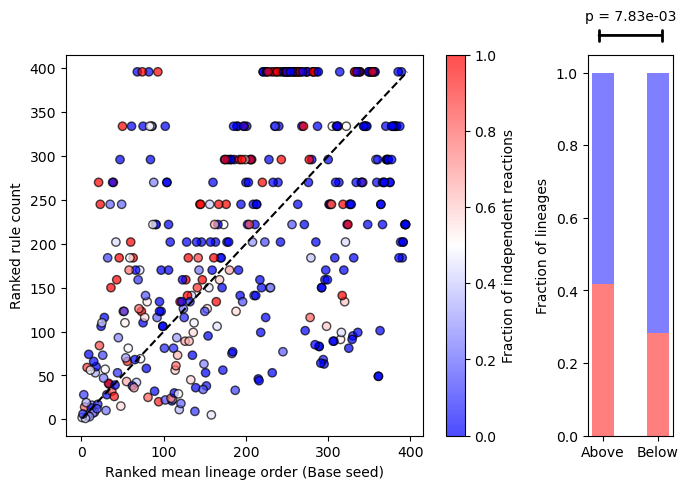

redAbove: 88
blueAbove: 132
redBelow: 44
blueBelow: 132


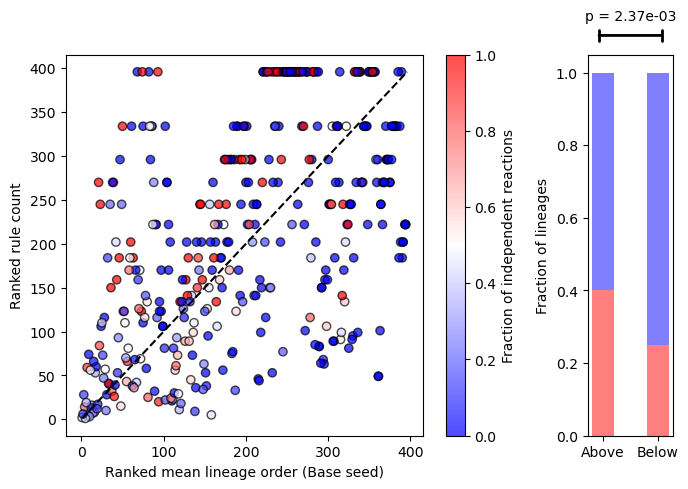

redAbove: 79
blueAbove: 141
redBelow: 34
blueBelow: 142


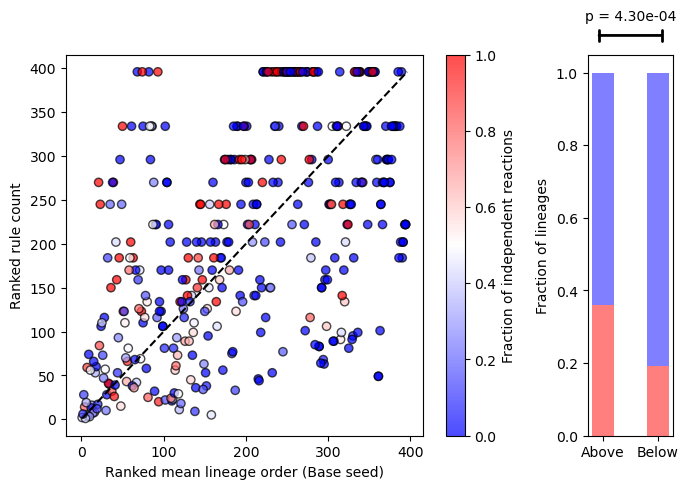

redAbove: 68
blueAbove: 152
redBelow: 27
blueBelow: 149


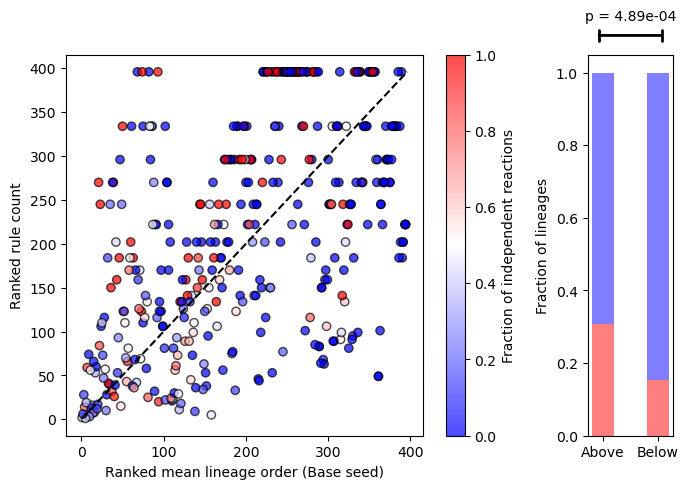

redAbove: 66
blueAbove: 154
redBelow: 16
blueBelow: 160


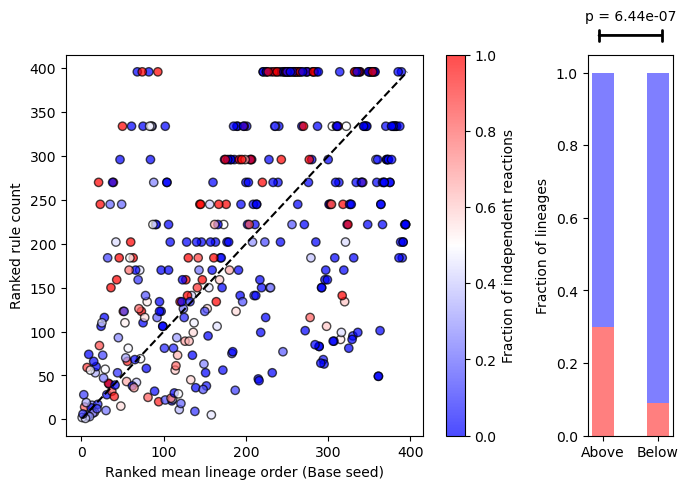

In [57]:
dx = x2foMean_NONE_rank
dy = x2rulesNum_rank
# dz = x2loading1
dz = x2indepRnFrac

for frac in [0.3, 0.4, 0.5, 0.6, 0.7]:
    barplot2(dx, dy, dz, frac, 'Ranked mean lineage order (Base seed)', 'Ranked rule count', 'Fraction of independent reactions')

redAbove: 132
blueAbove: 137
redBelow: 10
blueBelow: 117


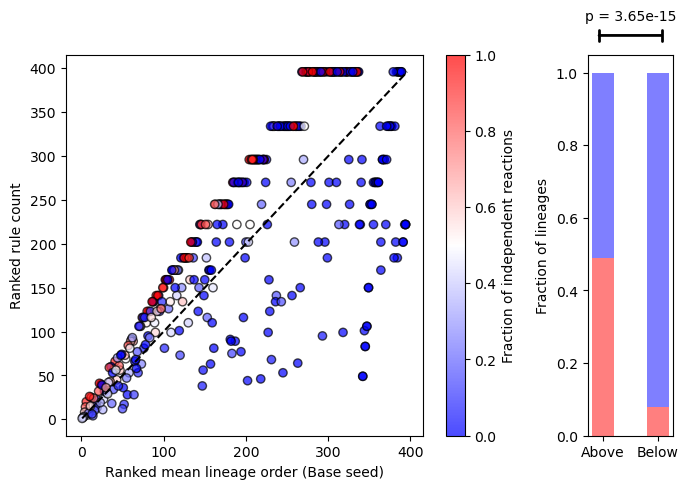

redAbove: 125
blueAbove: 144
redBelow: 7
blueBelow: 120


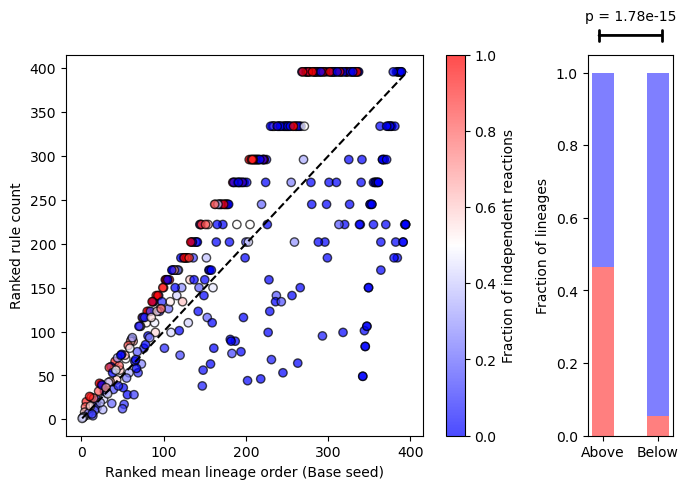

redAbove: 113
blueAbove: 156
redBelow: 0
blueBelow: 127


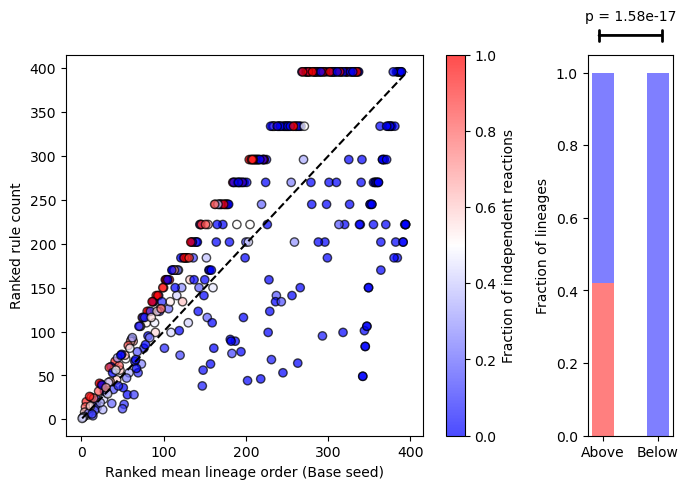

redAbove: 95
blueAbove: 174
redBelow: 0
blueBelow: 127


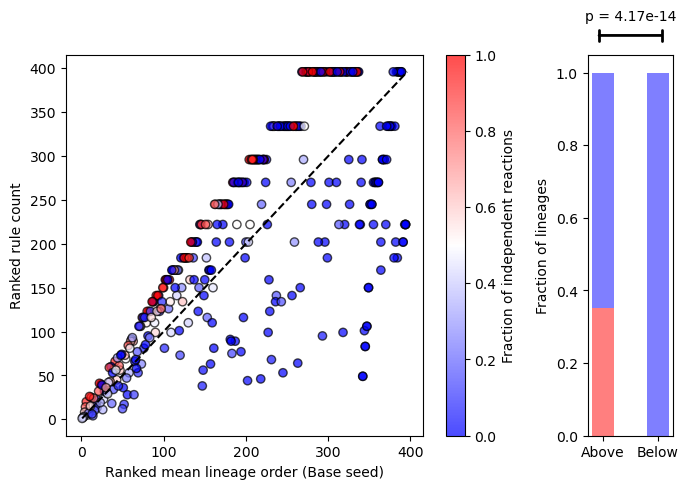

redAbove: 82
blueAbove: 187
redBelow: 0
blueBelow: 127


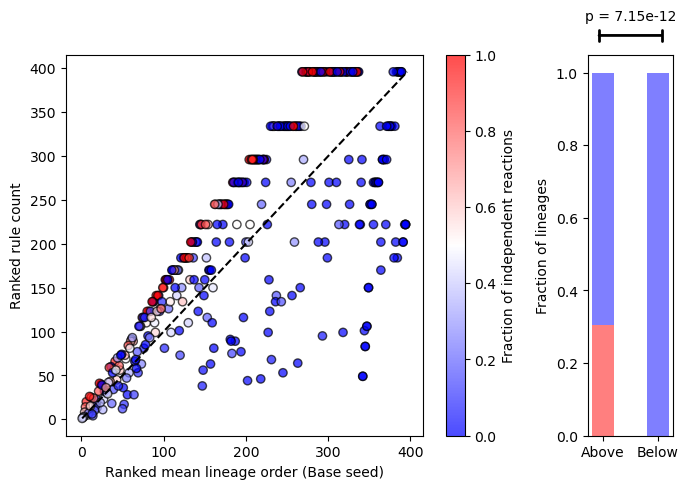

In [58]:
dx = x2foMean_ALL_rank
dy = x2rulesNum_rank
# dz = x2loading1
dz = x2indepRnFrac

for frac in [0.3, 0.4, 0.5, 0.6, 0.7]:
    barplot2(dx, dy, dz, frac, 'Ranked mean lineage order (Base seed)', 'Ranked rule count', 'Fraction of independent reactions')

redAbove: 79
blueAbove: 141
redBelow: 34
blueBelow: 142


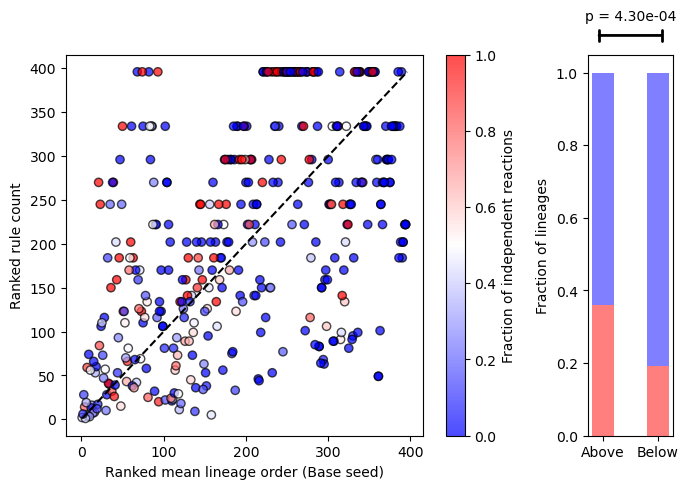

redAbove: 90
blueAbove: 138
redBelow: 23
blueBelow: 145


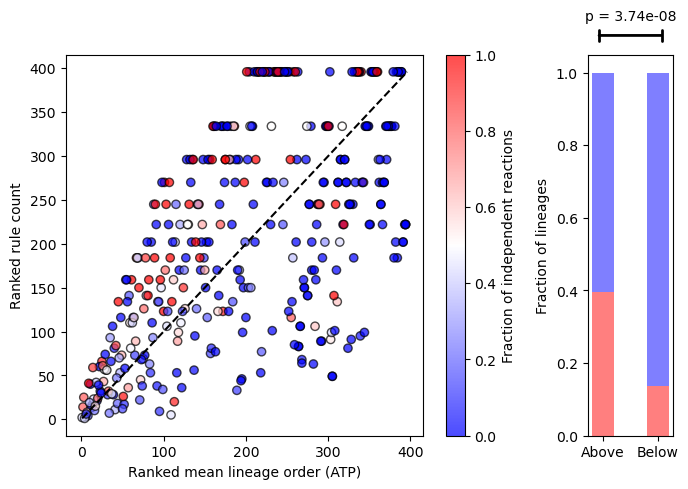

redAbove: 113
blueAbove: 156
redBelow: 0
blueBelow: 127


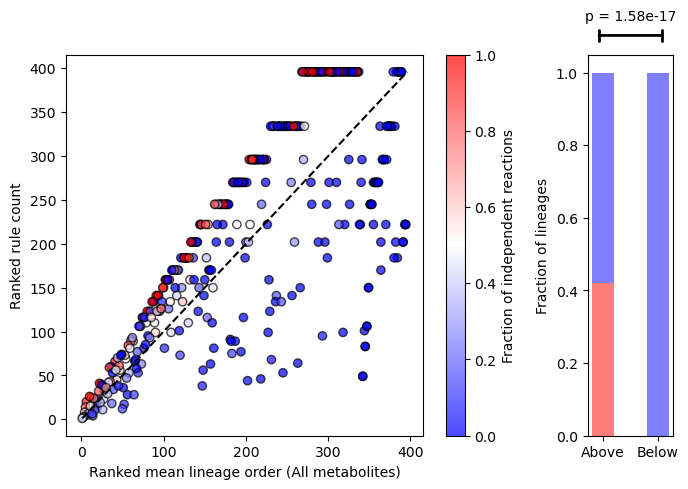

In [59]:
# let's go with 0.5
frac = 0.5

dx = x2foMean_NONE_rank
dy = x2rulesNum_rank
dz = x2indepRnFrac
barplot2(dx, dy, dz, frac, 'Ranked mean lineage order (Base seed)', 'Ranked rule count', 'Fraction of independent reactions', savefig=False)

dx = x2foMean_C00002_rank
dy = x2rulesNum_rank
dz = x2indepRnFrac
barplot2(dx, dy, dz, frac, 'Ranked mean lineage order (ATP)', 'Ranked rule count', 'Fraction of independent reactions', savefig=False)

dx = x2foMean_ALL_rank
dy = x2rulesNum_rank
dz = x2indepRnFrac
barplot2(dx, dy, dz, frac, 'Ranked mean lineage order (All metabolites)', 'Ranked rule count', 'Fraction of independent reactions', savefig=False)

# look more into loading 2

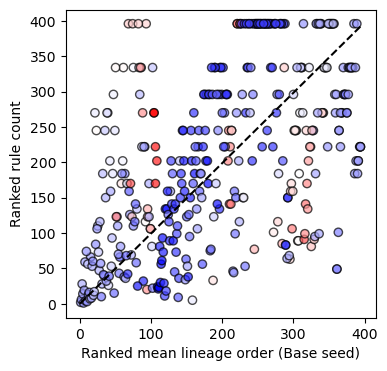

Lineage order (Base seed) vs. #rules: corr = 0.5343631943580014, p_value = 1.2780442542861007e-30


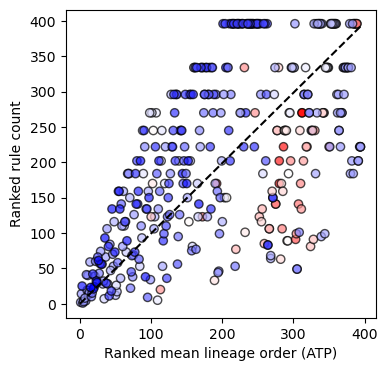

Lineage order (ATP) vs. #rules: corr = -0.6248090967302833, p_value = 2.898927813476995e-44


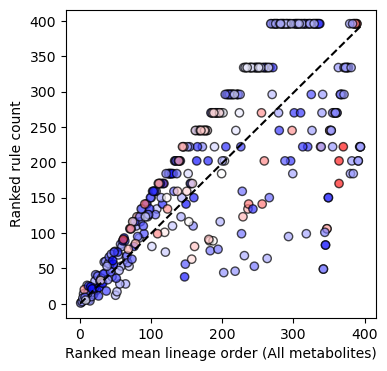

Lineage order (All metabolites) vs. #rules: corr = -0.7567771282116064, p_value = 9.466443311657558e-75


In [60]:
scatterColor(x2foMean_NONE_rank, x2rulesNum_rank, x2loading2, 'Ranked mean lineage order (Base seed)', 'Ranked rule count', 'Loading (PC2)', line=True)
corr, p = spearman(x2foMean_NONE_rank, x2rulesNum_rank)
print(f'Lineage order (Base seed) vs. #rules: corr = {corr}, p_value = {p}')

scatterColor(x2foMean_ATP_rank, x2rulesNum_rank, x2loading2, 'Ranked mean lineage order (ATP)', 'Ranked rule count', 'Loading (PC2)', line=True)
corr, p = spearman(x2foMean_ATP_rank, x2rulesNum_scope)
print(f'Lineage order (ATP) vs. #rules: corr = {corr}, p_value = {p}')

scatterColor(x2foMean_ALL_rank, x2rulesNum_rank, x2loading2, 'Ranked mean lineage order (All metabolites)', 'Ranked rule count', 'Loading (PC2)', line=True)
corr, p = spearman(x2foMean_ALL_rank, x2rulesNum_scope)
print(f'Lineage order (All metabolites) vs. #rules: corr = {corr}, p_value = {p}')

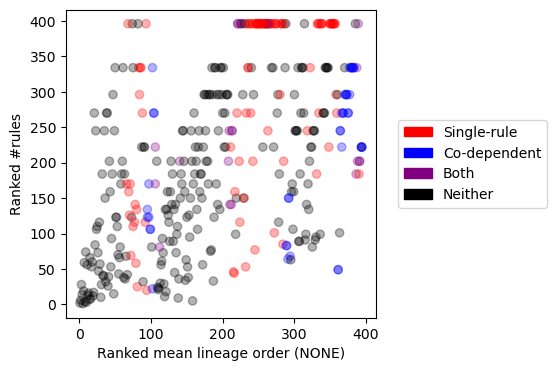

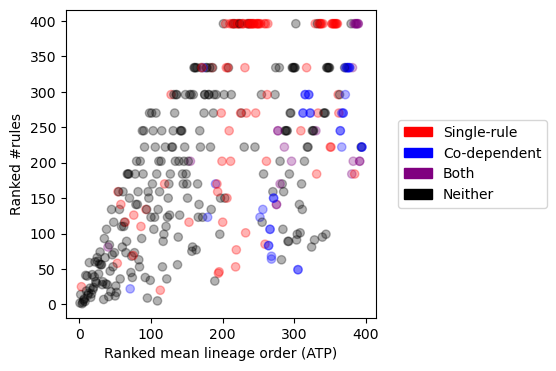

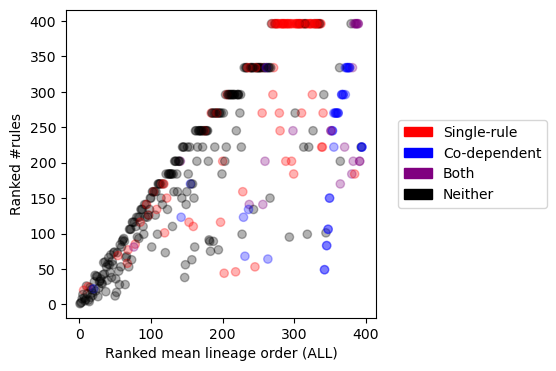

In [61]:
def scatterCustom(x, y, pre):

    plt.figure(figsize=(4, 4))
    valid_keys, data1, data2 = todata(x, y)
    
    # Define colors based on boolean conditions
    colors = [
        'red' if (key in single_rule and key not in codependent) else 
        'blue' if (key in codependent and key not in single_rule) else 
        'purple' if (key in codependent and key in single_rule) else 
        'black' 
        for key in valid_keys
    ]
    
    # Create scatter plot
    plt.scatter(data1, data2, marker='o', color=colors, alpha=0.3, label='Data Points', zorder=2)
    plt.xlabel(f'Ranked mean lineage order ({pre})')
    plt.ylabel('Ranked #rules')
    
    # Create legend manually
    legend_patches = [
        mpatches.Patch(color='red', label='Single-rule'),
        mpatches.Patch(color='blue', label='Co-dependent'),
        mpatches.Patch(color='purple', label='Both'),
        mpatches.Patch(color='black', label='Neither')
    ]
    plt.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.05, 0.5))
    
    # Save and show the plot
    # plt.savefig(f'foMean_fo_vs_foStd_{pre}.svg')
    plt.show()

scatterCustom(x2foMean_NONE_rank, x2rulesNum_rank, 'NONE')
scatterCustom(x2foMean_ATP_rank, x2rulesNum_rank, 'ATP')
scatterCustom(x2foMean_ALL_rank, x2rulesNum_rank, 'ALL')

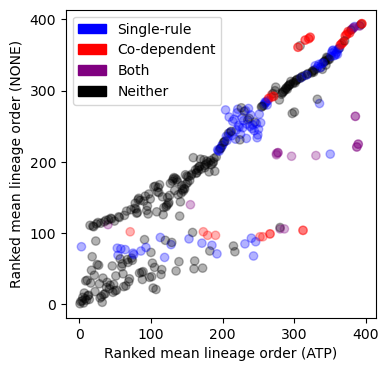

Lineage order (ATP) vs. Lineage order (Base seed): corr = 0.8909959422736466, p_value = 3.451508727183999e-137


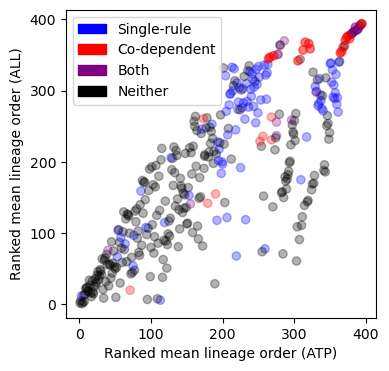

Lineage order (ATP) vs. Lineage order (All metabolites): corr = 0.8298399683161866, p_value = 7.223522011895414e-102


In [62]:
def scatterCustom2(x, y, pre1, pre2):

    plt.figure(figsize=(4, 4))
    valid_keys, data1, data2 = todata(x, y)
    
    # Define colors based on boolean conditions
    colors = [
        'blue' if (key in single_rule and key not in codependent) else 
        'red' if (key in codependent and key not in single_rule) else 
        'purple' if (key in codependent and key in single_rule) else 
        'black' 
        for key in valid_keys
    ]
    
    # Create scatter plot
    plt.scatter(data1, data2, marker='o', color=colors, alpha=0.3, label='Data Points', zorder=2)
    plt.xlabel(f'Ranked mean lineage order ({pre1})')
    plt.ylabel(f'Ranked mean lineage order ({pre2})')
    plt.yticks([0, 100, 200, 300, 400])
    
    # Create legend manually
    legend_patches = [
        mpatches.Patch(color='blue', label='Single-rule'),
        mpatches.Patch(color='red', label='Co-dependent'),
        mpatches.Patch(color='purple', label='Both'),
        mpatches.Patch(color='black', label='Neither')
    ]
    plt.legend(handles=legend_patches, loc='upper left')
    
    # Save and show the plot
    # plt.savefig(f'foMean_{pre1}_vs_{pre2}.svg')
    plt.show()

scatterCustom2(x2foMean_C00002_rank, x2foMean_NONE_rank, 'ATP', 'NONE')
corr, p = spearman(x2foMean_C00002_rank, x2foMean_NONE_rank)
print(f'Lineage order (ATP) vs. Lineage order (Base seed): corr = {corr}, p_value = {p}')

scatterCustom2(x2foMean_C00002_rank, x2foMean_ALL_rank, 'ATP', 'ALL')
corr, p = spearman(x2foMean_C00002_rank, x2foMean_ALL_rank)
print(f'Lineage order (ATP) vs. Lineage order (All metabolites): corr = {corr}, p_value = {p}')